In [1]:
import os, time, random, warnings
warnings.filterwarnings("ignore")

import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision.transforms.functional import rotate as tvrotate
from torchvision import transforms

def set_seed(s: int = 42):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device : {device}")

device : cuda


In [2]:
DATA_DIR   = "/kaggle/input/datasets/vitthal2945/e2e-hidden-symmetries-dataset"
OUT_DIR    = "/kaggle/working/exp1_heun_flow"
LATENT_DIM = 16          

EPOCHS_ORACLE = 15
EPOCHS_G      = 60
BATCH_SIZE    = 256
LR_G          = 3e-4

# Loss weights
W_SUP    = 1.0   
W_MULTI  = 0.4   
W_CYCLE  = 0.05  
W_ORACLE = 0.1   

TASK1_CKPT = "/kaggle/input/models/vitthal2945/e2e-vaemodel/pytorch/default/1/best_model.pt"

os.makedirs(OUT_DIR, exist_ok=True)
print(f"output → {OUT_DIR}")

output → /kaggle/working/exp1_heun_flow


In [3]:
def load_h5(path: str):
    print(f"  loading {os.path.basename(path)} ...", end=" ", flush=True)
    t0 = time.time()
    with h5py.File(path, "r") as f:
        imgs   = torch.from_numpy(f["images"][:].astype("float32")).unsqueeze(1)
        labels = torch.from_numpy(f["labels"][:].astype("int64"))
        angles = torch.from_numpy(f["angles"][:].astype("int64"))
    imgs = imgs.clamp(0., 1.)
    print(f"done  ({imgs.nbytes/1e6:.0f} MB, {time.time()-t0:.1f}s)")
    return imgs, labels, angles

train_imgs, train_lbls, train_angs = load_h5(os.path.join(DATA_DIR, "rotated_mnist_train.h5"))
test_imgs,  test_lbls,  test_angs  = load_h5(os.path.join(DATA_DIR, "rotated_mnist_test.h5"))

ANGLES  = sorted(train_angs.unique().tolist())
DIGITS  = sorted(train_lbls.unique().tolist())
DIG_MAP = {d: i for i, d in enumerate(DIGITS)}
TARGET  = [a for a in ANGLES if a != 0]

pin = device.type == "cuda"
train_loader = DataLoader(TensorDataset(train_imgs, train_lbls, train_angs),
                          batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=pin)
test_loader  = DataLoader(TensorDataset(test_imgs, test_lbls, test_angs),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=pin)
print(f"train: {len(train_imgs):,}   test: {len(test_imgs):,}")

  loading rotated_mnist_train.h5 ... done  (478 MB, 2.1s)
  loading rotated_mnist_test.h5 ... done  (82 MB, 0.4s)
train: 152,400   test: 26,004


In [4]:
class ResBlock(nn.Module):
    def __init__(self, ch, g=8):
        super().__init__()
        g = min(g, ch)
        self.net = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.GroupNorm(g, ch), nn.SiLU(),
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.GroupNorm(g, ch),
        )
        self.act = nn.SiLU()
    def forward(self, x): return self.act(x + self.net(x))

class T1Encoder(nn.Module):
    def __init__(self, ld):
        super().__init__()
        self.stem  = nn.Sequential(nn.Conv2d(1, 32, 4, 2, 1, bias=False), nn.GroupNorm(8, 32),  nn.SiLU())
        self.l1    = nn.Sequential(ResBlock(32),  nn.Conv2d(32,  64, 4, 2, 1, bias=False), nn.GroupNorm(8, 64),  nn.SiLU())
        self.l2    = nn.Sequential(ResBlock(64),  nn.Conv2d(64, 128, 3, 2, 1, bias=False), nn.GroupNorm(8, 128), nn.SiLU())
        self.l3    = ResBlock(128)
        self.fc    = nn.Sequential(nn.Flatten(), nn.Linear(128*4*4, 512), nn.SiLU())
        self.fc_mu = nn.Linear(512, ld)
        self.fc_lv = nn.Linear(512, ld)
    def forward(self, x):
        h = self.l3(self.l2(self.l1(self.stem(x))))
        h = self.fc(h)
        return self.fc_mu(h), self.fc_lv(h)

class T1Decoder(nn.Module):
    def __init__(self, ld):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(ld, 512), nn.SiLU(), nn.Linear(512, 128*4*4), nn.SiLU())
        self.u1 = nn.Sequential(ResBlock(128), nn.ConvTranspose2d(128, 64, 3, 2, 1, output_padding=1), nn.GroupNorm(8, 64),  nn.SiLU())
        self.u2 = nn.Sequential(ResBlock(64),  nn.ConvTranspose2d(64,  32, 4, 2, 1),                  nn.GroupNorm(8, 32),  nn.SiLU())
        self.u3 = nn.Sequential(ResBlock(32),  nn.ConvTranspose2d(32,   1, 4, 2, 3),                  nn.Sigmoid())
    def forward(self, z): return self.u3(self.u2(self.u1(self.fc(z).view(-1, 128, 4, 4))))

class Task1VAE(nn.Module):
    def __init__(self, ld):
        super().__init__()
        self.encoder = T1Encoder(ld)
        self.decoder = T1Decoder(ld)
    def reparameterise(self, mu, lv):
        return mu + torch.randn_like(mu) * (0.5 * lv).exp() if self.training else mu
    def encode(self, x): return self.encoder(x)
    def decode(self, z): return self.decoder(z)
    def forward(self, x):
        mu, lv = self.encoder(x)
        return self.decoder(self.reparameterise(mu, lv)), mu, lv

vae = Task1VAE(LATENT_DIM).to(device)
if os.path.exists(TASK1_CKPT):
    ckpt = torch.load(TASK1_CKPT, map_location=device, weights_only=False)
    vae.load_state_dict(ckpt["model"])
    print(f"Task-1 VAE loaded (epoch {ckpt['epoch']})")
else:
    print("⚠ Task-1 checkpoint not found — VAE weights are random (replace TASK1_CKPT path)")

vae.eval()
for p in vae.parameters():
    p.requires_grad = False

enc_params = sum(p.numel() for p in vae.encoder.parameters())
print(f"Encoder: {enc_params:,} params [FROZEN]")

Task-1 VAE loaded (epoch 47)
Encoder: 1,560,928 params [FROZEN]


In [5]:
class Oracle(nn.Module):
    def __init__(self, ld, nc):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(ld, 128), nn.LayerNorm(128), nn.ReLU(),
            nn.Linear(128, 128), nn.LayerNorm(128), nn.ReLU(),
            nn.Linear(128, 32),  nn.ReLU(),
            nn.Linear(32, nc),
        )
    def forward(self, z): return self.net(z)

psi = Oracle(LATENT_DIM, len(DIGITS)).to(device)
opt_psi = torch.optim.Adam(psi.parameters(), lr=1e-3)
print(f"\nTraining Oracle for {EPOCHS_ORACLE} epochs …")

for ep in range(1, EPOCHS_ORACLE + 1):
    psi.train(); correct = total = 0
    for imgs, lbls, _ in train_loader:
        imgs = imgs.to(device, non_blocking=True)
        cls  = torch.tensor([DIG_MAP[l.item()] for l in lbls], device=device)
        with torch.no_grad():
            mu, _ = vae.encode(imgs)
        opt_psi.zero_grad()
        logits = psi(mu)
        F.cross_entropy(logits, cls).backward()
        opt_psi.step()
        correct += (logits.detach().argmax(1) == cls).sum().item()
        total   += imgs.size(0)
    if ep % 5 == 0 or ep == 1:
        print(f"  Oracle ep {ep:2d}/{EPOCHS_ORACLE}  acc={correct/total:.4f}")

psi.eval()
for p in psi.parameters():
    p.requires_grad = False
print("Oracle frozen.")

class ResidualMLP(nn.Module):
    """4-layer MLP with residual skip from input to output.
    The residual connection prevents g from collapsing to zero and
    regularises the vector field to stay near the identity perturbation."""
    def __init__(self, ld: int, hidden: int = 256):
        super().__init__()
        self.h1 = nn.Sequential(nn.Linear(ld, hidden),        nn.LayerNorm(hidden), nn.GELU())
        self.h2 = nn.Sequential(nn.Linear(hidden, hidden),    nn.LayerNorm(hidden), nn.GELU())
        self.h3 = nn.Sequential(nn.Linear(hidden, hidden),    nn.LayerNorm(hidden), nn.GELU())
        self.h4 = nn.Linear(hidden, ld)
        # small-init output layer — start near zero perturbation
        nn.init.uniform_(self.h4.weight, -0.01, 0.01)
        nn.init.zeros_(self.h4.bias)
    def forward(self, z):
        h = self.h1(z)
        h = self.h2(h)
        h = self.h3(h)
        return self.h4(h)   # pure displacement (added to z in Heun)

g = ResidualMLP(LATENT_DIM).to(device)
print(f"\nGenerator g params: {sum(p.numel() for p in g.parameters()):,}")


Training Oracle for 15 epochs …
  Oracle ep  1/15  acc=0.9849
  Oracle ep  5/15  acc=0.9886
  Oracle ep 10/15  acc=0.9888
  Oracle ep 15/15  acc=0.9892
Oracle frozen.

Generator g params: 141,584


In [6]:
def heun_step(z: torch.Tensor) -> torch.Tensor:
    """Single Heun (RK2) step: z → z + 30° in latent space."""
    k1 = g(z)
    k2 = g(z + k1)
    return z + 0.5 * (k1 + k2)

def heun_orbit(z0: torch.Tensor, n: int) -> torch.Tensor:
    """Apply n Heun steps (n × 30° in latent space)."""
    z = z0
    for _ in range(n):
        z = heun_step(z)
    return z

print("\n── Phase 2: Heun-RK2 Latent Symmetry Flow ────────────────────────")

opt_g   = torch.optim.AdamW(g.parameters(), lr=LR_G, weight_decay=1e-5)
sched_g = torch.optim.lr_scheduler.CosineAnnealingLR(opt_g, T_max=EPOCHS_G)

history = {k: [] for k in ["sup", "multi", "cycle", "oracle", "total", "val_90"]}
best_val = float("inf")

for ep in range(1, EPOCHS_G + 1):
    g.train()
    acc = {k: 0.0 for k in ["sup", "multi", "cycle", "oracle"]}
    n_batches = 0

    for imgs, _, _ in train_loader:
        imgs = imgs.to(device, non_blocking=True)

        # encode 0°, 30°, 60°, 90° (for multi-step supervision)
        img_30  = tvrotate(imgs, 30., interpolation=transforms.InterpolationMode.BILINEAR, fill=[0.])
        img_60  = tvrotate(imgs, 60., interpolation=transforms.InterpolationMode.BILINEAR, fill=[0.])
        img_90  = tvrotate(imgs, 90., interpolation=transforms.InterpolationMode.BILINEAR, fill=[0.])

        with torch.no_grad():
            z0,  _  = vae.encode(imgs)
            z30, _  = vae.encode(img_30)
            z60, _  = vae.encode(img_60)
            z90, _  = vae.encode(img_90)
            psi_z0  = psi(z0)

        opt_g.zero_grad(set_to_none=True)

        # ── L_sup: one Heun step ≈ E(rotate(x, 30°)) ──────────────────────
        z_hat = heun_step(z0)
        l_sup = F.mse_loss(z_hat, z30)

        # ── L_multi: k-step equivariance (k=2,3) ───────────────────────────
        z_2  = heun_step(z_hat)   # 2 steps ≈ 60°
        z_3  = heun_step(z_2)     # 3 steps ≈ 90°
        l_multi = (F.mse_loss(z_2, z60) + F.mse_loss(z_3, z90)) * 0.5

        # ── L_cycle: 12 steps = 360° → return to start ─────────────────────
        z_cyc = z0.clone()
        for _ in range(12):
            z_cyc = heun_step(z_cyc)
        l_cycle = F.mse_loss(z_cyc, z0)

        # ── L_oracle: class preservation after one step ─────────────────────
        l_oracle = F.mse_loss(psi(z_hat), psi_z0.detach())

        loss = W_SUP * l_sup + W_MULTI * l_multi + W_CYCLE * l_cycle + W_ORACLE * l_oracle
        loss.backward()
        nn.utils.clip_grad_norm_(g.parameters(), 1.0)
        opt_g.step()

        acc["sup"]    += l_sup.item()
        acc["multi"]  += l_multi.item()
        acc["cycle"]  += l_cycle.item()
        acc["oracle"] += l_oracle.item()
        n_batches += 1

    sched_g.step()
    for k in acc: acc[k] /= n_batches
    total = (W_SUP * acc["sup"] + W_MULTI * acc["multi"] +
             W_CYCLE * acc["cycle"] + W_ORACLE * acc["oracle"])

    # ── validation: 3-step accuracy (90°) on held-out 0° samples ───────────
    g.eval()
    with torch.no_grad():
        pool = (test_angs == 0).nonzero(as_tuple=True)[0][:300]
        x_val = test_imgs[pool].to(device)
        z_val, _ = vae.encode(x_val)
        x90_val = tvrotate(x_val, 90., interpolation=transforms.InterpolationMode.BILINEAR, fill=[0.])
        z_gt90, _ = vae.encode(x90_val)
        z_pred90 = heun_orbit(z_val, 3)
        val_90 = F.mse_loss(z_pred90, z_gt90).item()
    g.train()

    for k in acc: history[k].append(acc[k])
    history["total"].append(total)
    history["val_90"].append(val_90)

    if val_90 < best_val:
        best_val = val_90
        torch.save({"g": g.state_dict(), "psi": psi.state_dict(), "epoch": ep,
                    "val_90": best_val}, os.path.join(OUT_DIR, "best_model.pt"))
        tag = "  ★"
    else:
        tag = ""

    if ep % 5 == 0 or ep == 1 or tag:
        print(f"  ep {ep:3d}/{EPOCHS_G}  sup={acc['sup']:.5f}  multi={acc['multi']:.5f}  "
              f"cycle={acc['cycle']:.5f}  val_90={val_90:.5f}{tag}")

# load best
ck = torch.load(os.path.join(OUT_DIR, "best_model.pt"), weights_only=False)
g.load_state_dict(ck["g"]); psi.load_state_dict(ck["psi"])
g.eval()
print(f"Best model loaded (epoch {ck['epoch']}, val_90={ck['val_90']:.5f})")


── Phase 2: Heun-RK2 Latent Symmetry Flow ────────────────────────
  ep   1/60  sup=0.00675  multi=0.01510  cycle=0.03042  val_90=0.00551  ★
  ep   2/60  sup=0.00332  multi=0.00499  cycle=0.00548  val_90=0.00473  ★
  ep   3/60  sup=0.00283  multi=0.00394  cycle=0.00500  val_90=0.00317  ★
  ep   4/60  sup=0.00245  multi=0.00305  cycle=0.00330  val_90=0.00254  ★
  ep   5/60  sup=0.00218  multi=0.00248  cycle=0.00257  val_90=0.00241  ★
  ep   6/60  sup=0.00196  multi=0.00213  cycle=0.00192  val_90=0.00188  ★
  ep   7/60  sup=0.00182  multi=0.00197  cycle=0.00192  val_90=0.00180  ★
  ep   8/60  sup=0.00169  multi=0.00183  cycle=0.00173  val_90=0.00175  ★
  ep  10/60  sup=0.00153  multi=0.00167  cycle=0.00153  val_90=0.00167  ★
  ep  11/60  sup=0.00148  multi=0.00160  cycle=0.00143  val_90=0.00159  ★
  ep  12/60  sup=0.00141  multi=0.00153  cycle=0.00129  val_90=0.00151  ★
  ep  13/60  sup=0.00138  multi=0.00149  cycle=0.00127  val_90=0.00150  ★
  ep  15/60  sup=0.00131  multi=0.00143  cyc

In [7]:
@torch.no_grad()
def evaluate():
    pool = (test_angs == 0).nonzero(as_tuple=True)[0][:500]
    x0   = test_imgs[pool].to(device)
    z0, _ = vae.encode(x0)

    # M1 — per-angle latent MSE (Heun rollout vs. E(rotate(x,θ)))
    m1_per = {}
    for theta in TARGET:
        xr = tvrotate(x0, float(theta), interpolation=transforms.InterpolationMode.BILINEAR, fill=[0.])
        z_gt, _ = vae.encode(xr)
        n_steps  = int(round(theta / 30))
        z_pred   = heun_orbit(z0, n_steps)
        m1_per[theta] = F.mse_loss(z_pred, z_gt).item()

    m1_mean = float(np.mean(list(m1_per.values())))

    # M2 — oracle drift after 360° (class identity should be preserved)
    p0    = torch.softmax(psi(z0), dim=1)
    z360  = heun_orbit(z0, 12)
    m2    = F.mse_loss(torch.softmax(psi(z360), dim=1), p0).item()

    # M3 — step norm statistics (how large each latent step is)
    dz    = g(z0)          # raw displacement before Heun correction
    m3m   = dz.norm(dim=1).mean().item()
    m3s   = dz.norm(dim=1).std().item()

    # M4 — cycle closure: |heun^12(z) - z| / |z|
    m4    = (z360 - z0).norm(dim=1).mean().item() / (z0.norm(dim=1).mean().item() + 1e-8)

    # M5 — multi-step consistency (3-step vs direct 90°)
    xr90  = tvrotate(x0, 90., interpolation=transforms.InterpolationMode.BILINEAR, fill=[0.])
    z_gt90, _ = vae.encode(xr90)
    z3    = heun_orbit(z0, 3)
    m5    = F.mse_loss(z3, z_gt90).item()

    return m1_per, m1_mean, m2, m3m, m3s, m4, m5

m1_per, m1_mean, m2, m3m, m3s, m4, m5 = evaluate()
print("\n══════════════ FINAL METRICS ══════════════")
print(f"M1 Latent MSE (mean over angles) : {m1_mean:.5f}")
for theta, v in m1_per.items():
    print(f"     θ={theta:4d}°  →  {v:.5f}")
print(f"M2 Oracle drift (360°)           : {m2:.5f}")
print(f"M3 Step norm  mean ± std         : {m3m:.4f} ± {m3s:.4f}")
print(f"M4 Cycle closure (rel)           : {m4:.5f}")
print(f"M5 3-step (90°) MSE              : {m5:.5f}")
print("═══════════════════════════════════════════")

np.save(os.path.join(OUT_DIR, "metrics.npy"), {
    "exp": "EXP1_HEUN_RK2_FLOW",
    "m1_per_angle": m1_per, "m1_mean": m1_mean,
    "m2_oracle_drift": m2,
    "m3_norm_mean": m3m, "m3_norm_std": m3s,
    "m4_cycle_closure": m4,
    "m5_multistep_90": m5,
    "history": history,
}, allow_pickle=True)


══════════════ FINAL METRICS ══════════════
M1 Latent MSE (mean over angles) : 0.00094
     θ=  30°  →  0.00100
     θ=  60°  →  0.00086
     θ=  90°  →  0.00087
     θ= 120°  →  0.00106
     θ= 150°  →  0.00081
     θ= 180°  →  0.00089
     θ= 210°  →  0.00138
     θ= 240°  →  0.00104
     θ= 270°  →  0.00073
     θ= 300°  →  0.00083
     θ= 330°  →  0.00089
M2 Oracle drift (360°)           : 0.00021
M3 Step norm  mean ± std         : 0.6362 ± 0.1971
M4 Cycle closure (rel)           : 0.09354
M5 3-step (90°) MSE              : 0.00087
═══════════════════════════════════════════


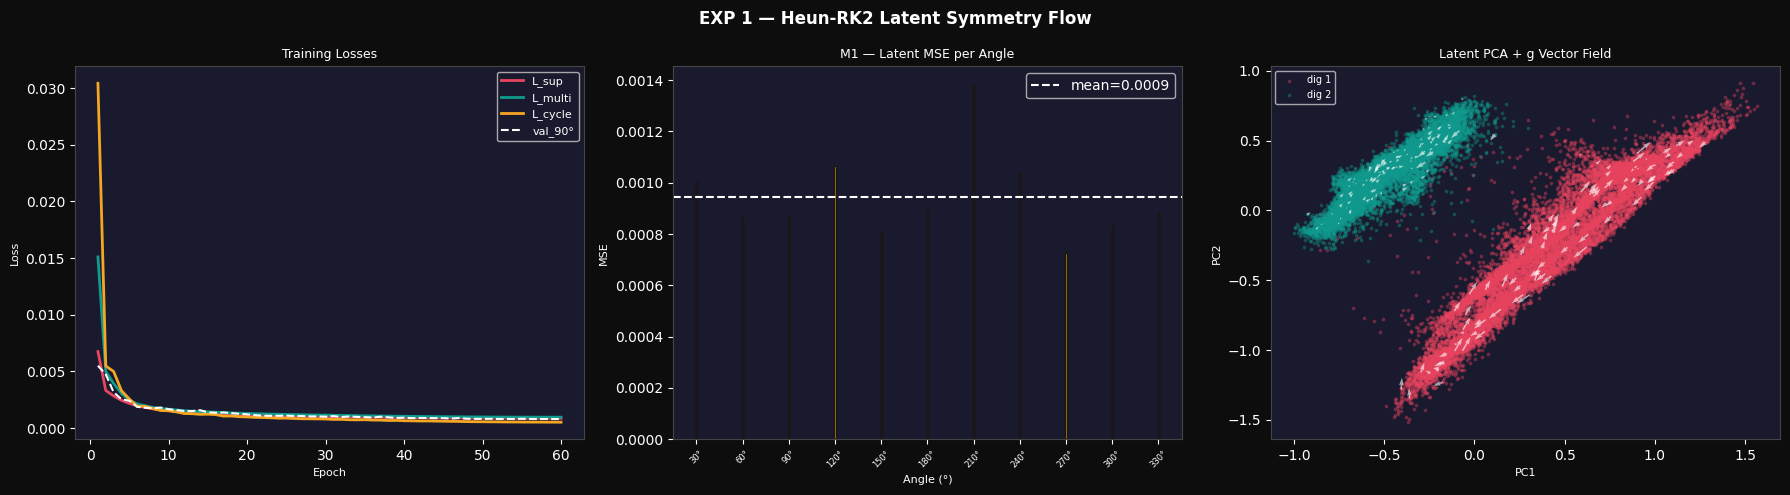

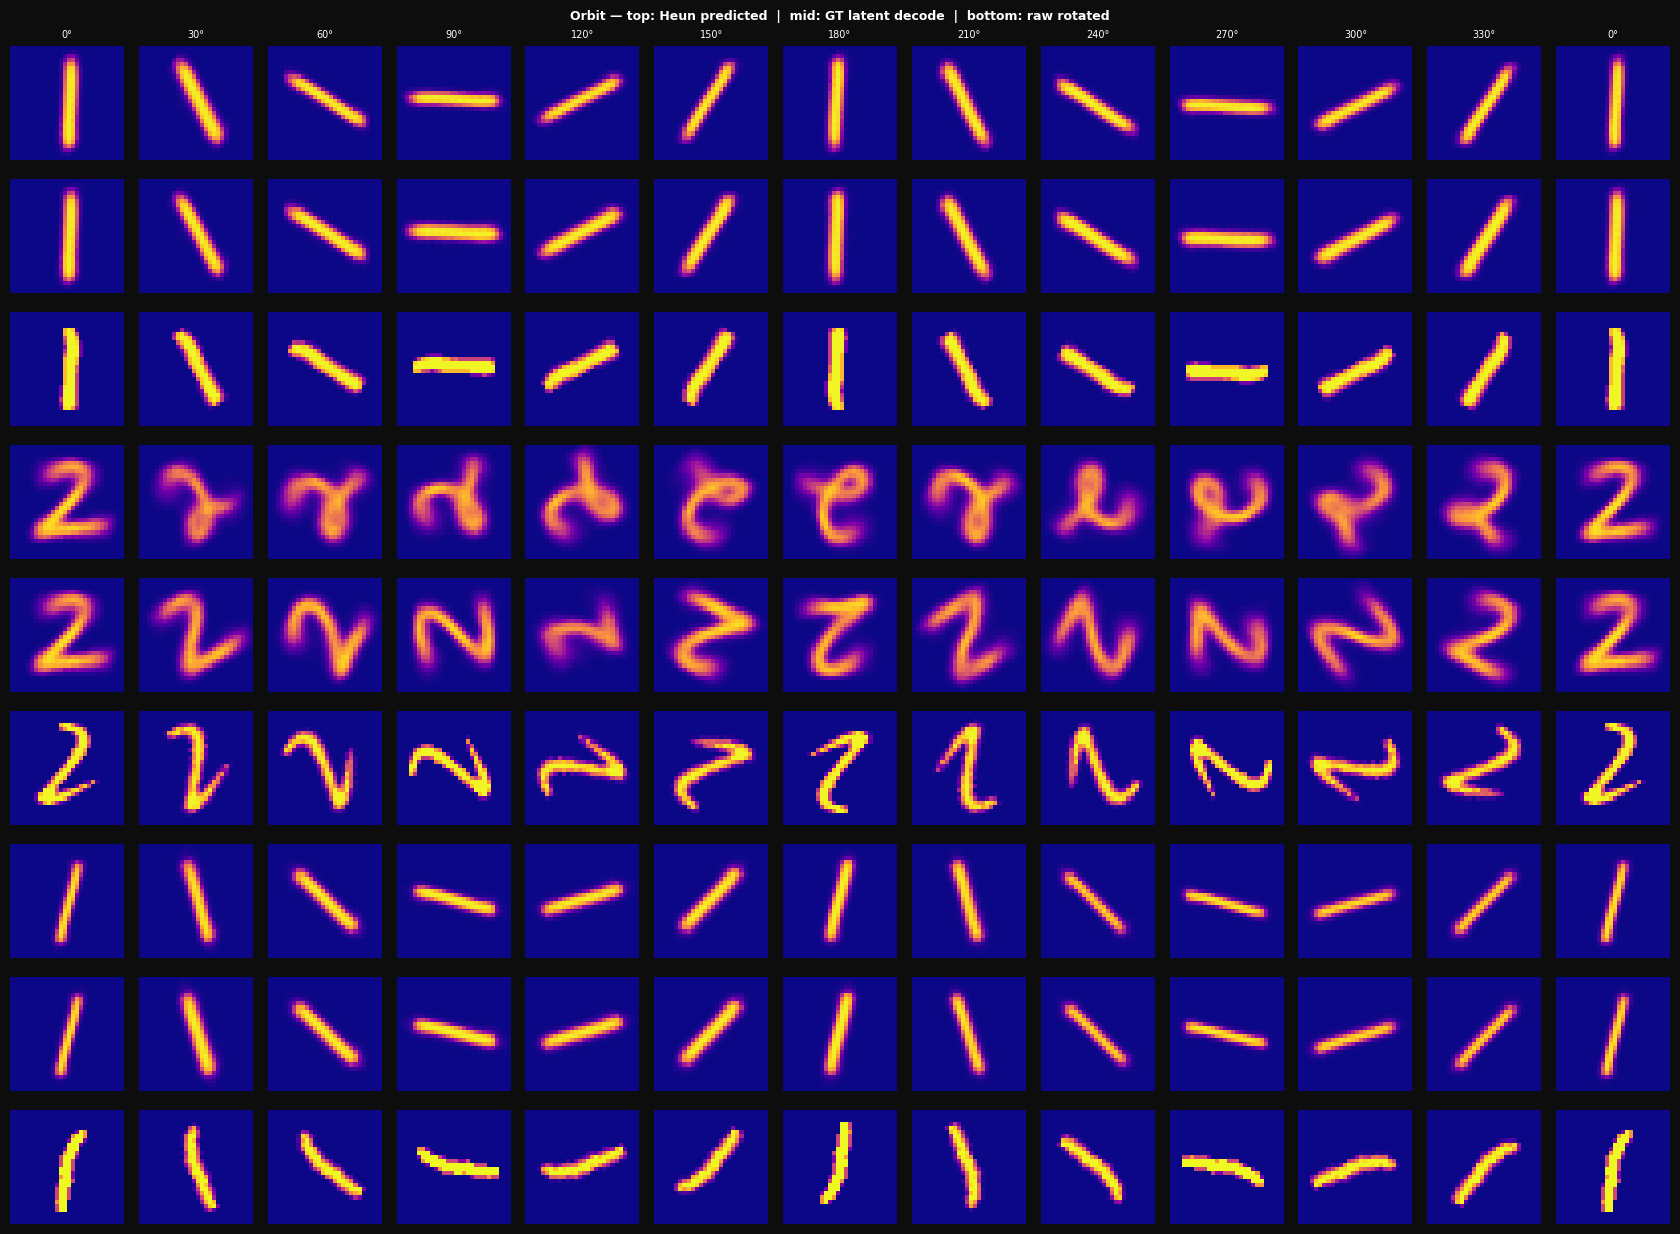


✅ EXP 1 (Heun-RK2 Flow) complete
   M1=0.00094  M2=0.00021  M4=0.09354  M5=0.00087


In [8]:
DARK = "#0d0d0d"; PANEL = "#1a1a2e"

def _ax(ax, title="", xl="", yl=""):
    ax.set_facecolor(PANEL)
    ax.tick_params(colors="white")
    for s in ax.spines.values(): s.set_edgecolor("#444")
    if title: ax.set_title(title, color="white", fontsize=9)
    if xl:    ax.set_xlabel(xl, color="white", fontsize=8)
    if yl:    ax.set_ylabel(yl, color="white", fontsize=8)

# ── figure 1: training curves + per-angle MSE + latent PCA ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor=DARK)
fig.suptitle("EXP 1 — Heun-RK2 Latent Symmetry Flow", color="white", fontsize=12, fontweight="bold")

ep_ax = range(1, EPOCHS_G + 1)
_ax(axes[0], "Training Losses", "Epoch", "Loss")
axes[0].plot(ep_ax, history["sup"],    color="#e94560", lw=2, label="L_sup")
axes[0].plot(ep_ax, history["multi"],  color="#0f9b8e", lw=2, label="L_multi")
axes[0].plot(ep_ax, history["cycle"],  color="#f5a623", lw=2, label="L_cycle")
axes[0].plot(ep_ax, history["val_90"], color="white",   lw=1.5, ls="--", label="val_90°")
axes[0].legend(facecolor=PANEL, labelcolor="white", fontsize=8)

_ax(axes[1], "M1 — Latent MSE per Angle", "Angle (°)", "MSE")
angles_list = list(m1_per.keys()); mse_list = list(m1_per.values())
axes[1].bar(angles_list, mse_list, color="#f5a623", alpha=0.85, edgecolor=DARK)
axes[1].axhline(m1_mean, color="white", ls="--", lw=1.5, label=f"mean={m1_mean:.4f}")
axes[1].set_xticks(angles_list)
axes[1].set_xticklabels([f"{a}°" for a in angles_list], color="white", fontsize=6, rotation=45)
axes[1].legend(facecolor=PANEL, labelcolor="white")

# latent PCA with g vector field
with torch.no_grad():
    Zs, Ls = [], []
    for imgs, lbls, _ in test_loader:
        mu, _ = vae.encode(imgs.to(device))
        Zs.append(mu.cpu().numpy()); Ls.append(lbls.numpy())
Z_all = np.concatenate(Zs); L_all = np.concatenate(Ls)
pca   = PCA(n_components=2).fit(Z_all)
Z2    = pca.transform(Z_all)

_ax(axes[2], "Latent PCA + g Vector Field", "PC1", "PC2")
COLORS = ["#e94560","#0f9b8e","#5bc0de","#f0ad4e","#9b59b6",
          "#2ecc71","#ff7f7f","#7f8c8d","#1abc9c","#3498db"]
for i, d in enumerate(DIGITS):
    mask = (L_all == d)
    axes[2].scatter(Z2[mask, 0], Z2[mask, 1], s=3, alpha=0.3,
                    color=COLORS[i % len(COLORS)], label=f"dig {d}")

idx = np.random.choice(len(Z_all), min(200, len(Z_all)), replace=False)
Z_g = torch.from_numpy(Z_all[idx]).to(device)
with torch.no_grad():
    dz_pca = g(Z_g).cpu().numpy() @ pca.components_.T
axes[2].quiver(Z2[idx, 0], Z2[idx, 1], dz_pca[:, 0], dz_pca[:, 1],
               color="white", alpha=0.6, scale=30, width=0.003)
axes[2].legend(facecolor=PANEL, labelcolor="white", fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "results.png"), dpi=150, bbox_inches="tight", facecolor=DARK)
plt.show()

# ── figure 2: orbit sequences ────────────────────────────────────────────────
@torch.no_grad()
def plot_orbit(n_samples: int = 3):
    pool = (test_angs == 0).nonzero(as_tuple=True)[0][:n_samples]
    x0   = test_imgs[pool].to(device)
    z0, _ = vae.encode(x0)

    n_show = 12
    fig, axes = plt.subplots(n_samples * 3, n_show + 1,
                              figsize=((n_show + 1) * 1.3, n_samples * 4.2),
                              facecolor=DARK)
    fig.suptitle("Orbit — top: Heun predicted  |  mid: GT latent decode  |  bottom: raw rotated",
                 color="white", fontsize=9, fontweight="bold")

    for row in range(n_samples):
        z = z0[row:row+1].clone()
        for col in range(n_show + 1):
            angle = (col * 30) % 360
            xr = x0[row:row+1] if angle == 0 else tvrotate(
                x0[row:row+1], float(angle),
                interpolation=transforms.InterpolationMode.BILINEAR, fill=[0.])

            # row 0: Heun-predicted reconstruction
            pred = vae.decode(z).clamp(0., 1.).cpu().squeeze().numpy()
            axes[row*3,   col].imshow(pred, cmap="plasma", vmin=0, vmax=1)
            axes[row*3,   col].axis("off")

            # row 1: GT latent decode
            z_gt, _ = vae.encode(xr)
            gt_dec  = vae.decode(z_gt).clamp(0., 1.).cpu().squeeze().numpy()
            axes[row*3+1, col].imshow(gt_dec, cmap="plasma", vmin=0, vmax=1)
            axes[row*3+1, col].axis("off")

            # row 2: raw rotated pixel image
            axes[row*3+2, col].imshow(xr.cpu().squeeze().numpy(), cmap="plasma", vmin=0, vmax=1)
            axes[row*3+2, col].axis("off")

            if row == 0:
                axes[0, col].set_title(f"{angle}°", color="white", fontsize=7)

            z = heun_step(z)

    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "orbit.png"), dpi=150, bbox_inches="tight", facecolor=DARK)
    plt.show()

plot_orbit()

print(f"\n✅ EXP 1 (Heun-RK2 Flow) complete")
print(f"   M1={m1_mean:.5f}  M2={m2:.5f}  M4={m4:.5f}  M5={m5:.5f}")